# MFCC（Mel 周波数ケプストラム係数）による音色解析

MFCC は人間の聴覚特性を模倣した音色の「指紋」。音声認識・楽器分類・音色比較の標準的な特徴量。

## このノートブックで学ぶこと

1. MFCC の計算パイプラインと各ステップの意味
2. MFCC・Δ MFCC・ΔΔ MFCC の違い
3. 複数の音色を MFCC で比較・類似度行列の作成
4. PCA で音色空間を可視化する方法

**素材音**: Karplus-Strong 法で生成した様々な周波数・`decay` 係数の音

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import librosa
import librosa.display
import soundfile as sf
from pathlib import Path
from scipy.spatial.distance import cosine
from scipy.fft import rfft, rfftfreq

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

SR = 44100
DATA_DIR = Path('../data/mfcc')
DATA_DIR.mkdir(parents=True, exist_ok=True)
print('準備完了')

準備完了


---
## 1. 素材音の生成

比較用に、**周波数** と **decay 係数** を変えた 6 種類の音を生成する。

| 名前 | 周波数 | decay | 特徴 |
|---|---|---|---|
| A3_bright | 220 Hz | 0.999 | 低音・長いサステイン |
| A4_bright | 440 Hz | 0.999 | 中音・長いサステイン |
| A5_bright | 880 Hz | 0.999 | 高音・長いサステイン |
| A3_damp   | 220 Hz | 0.990 | 低音・短いサステイン |
| A4_damp   | 440 Hz | 0.990 | 中音・短いサステイン |
| A5_damp   | 880 Hz | 0.990 | 高音・短いサステイン |

In [2]:
def karplus_strong(freq, duration, sr=44100, decay=0.996, seed=42):
    buf_size = max(2, int(round(sr / freq)))
    rng = np.random.default_rng(seed)
    buf = rng.uniform(-1.0, 1.0, buf_size)
    n = int(sr * duration)
    out = np.empty(n)
    for i in range(n):
        idx = i % buf_size
        out[i] = buf[idx]
        nxt = (idx + 1) % buf_size
        buf[idx] = decay * 0.5 * (buf[idx] + buf[nxt])
    peak = np.max(np.abs(out))
    return out / peak if peak > 0 else out


SOUNDS = {
    'A3_bright': dict(freq=220, decay=0.999),
    'A4_bright': dict(freq=440, decay=0.999),
    'A5_bright': dict(freq=880, decay=0.999),
    'A3_damp':   dict(freq=220, decay=0.990),
    'A4_damp':   dict(freq=440, decay=0.990),
    'A5_damp':   dict(freq=880, decay=0.990),
}

waves = {name: karplus_strong(p['freq'], 2.0, SR, p['decay'])
         for name, p in SOUNDS.items()}

# WAV 保存
for name, w in waves.items():
    sf.write(DATA_DIR / f'{name}.wav', w, SR)

print('生成・保存完了')
for name, p in SOUNDS.items():
    print(f'  {name}: {p["freq"]} Hz, decay={p["decay"]}')

生成・保存完了
  A3_bright: 220 Hz, decay=0.999
  A4_bright: 440 Hz, decay=0.999
  A5_bright: 880 Hz, decay=0.999
  A3_damp: 220 Hz, decay=0.99
  A4_damp: 440 Hz, decay=0.99
  A5_damp: 880 Hz, decay=0.99


---
## 2. MFCC 計算パイプラインの可視化

MFCC は以下のパイプラインで計算される。各ステップを順番に可視化する。

```
波形
 → STFTパワースペクトル
 → Mel フィルタバンク適用（Hz → Mel スケール変換）
 → 対数変換（dB）
 → DCT → MFCC 係数の選択
```

/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_88610/2275897358.py:58: UserWarning: Glyph 12497 (\N{KATAKANA LETTER PA}) missing from font(s) DejaVu Sans.
  plt.savefig(DATA_DIR / 'mfcc_pipeline.png', bbox_inches='tight')
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_88610/2275897358.py:58: UserWarning: Glyph 12527 (\N{KATAKANA LETTER WA}) missing from font(s) DejaVu Sans.
  plt.savefig(DATA_DIR / 'mfcc_pipeline.png', bbox_inches='tight')
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_88610/2275897358.py:58: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(DATA_DIR / 'mfcc_pipeline.png', bbox_inches='tight')
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_88610/2275897358.py:58: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.savefig(DATA_DIR / 'mfcc_pipeline.png', bbox_inches='tight')
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000

/Users/dolphilia/github/synth-lab/research/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12497 (\N{KATAKANA LETTER PA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dolphilia/github/synth-lab/research/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12527 (\N{KATAKANA LETTER WA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dolphilia/github/synth-lab/research/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dolphilia/github/synth-lab/research/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dolphilia/github/synth-lab/re

/Users/dolphilia/github/synth-lab/research/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20418 (\N{CJK UNIFIED IDEOGRAPH-4FC2}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dolphilia/github/synth-lab/research/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30058 (\N{CJK UNIFIED IDEOGRAPH-756A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dolphilia/github/synth-lab/research/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21495 (\N{CJK UNIFIED IDEOGRAPH-53F7}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dolphilia/github/synth-lab/research/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24460 (\N{CJK UNIFIED IDEOGRAPH-5F8C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dolphilia/github/

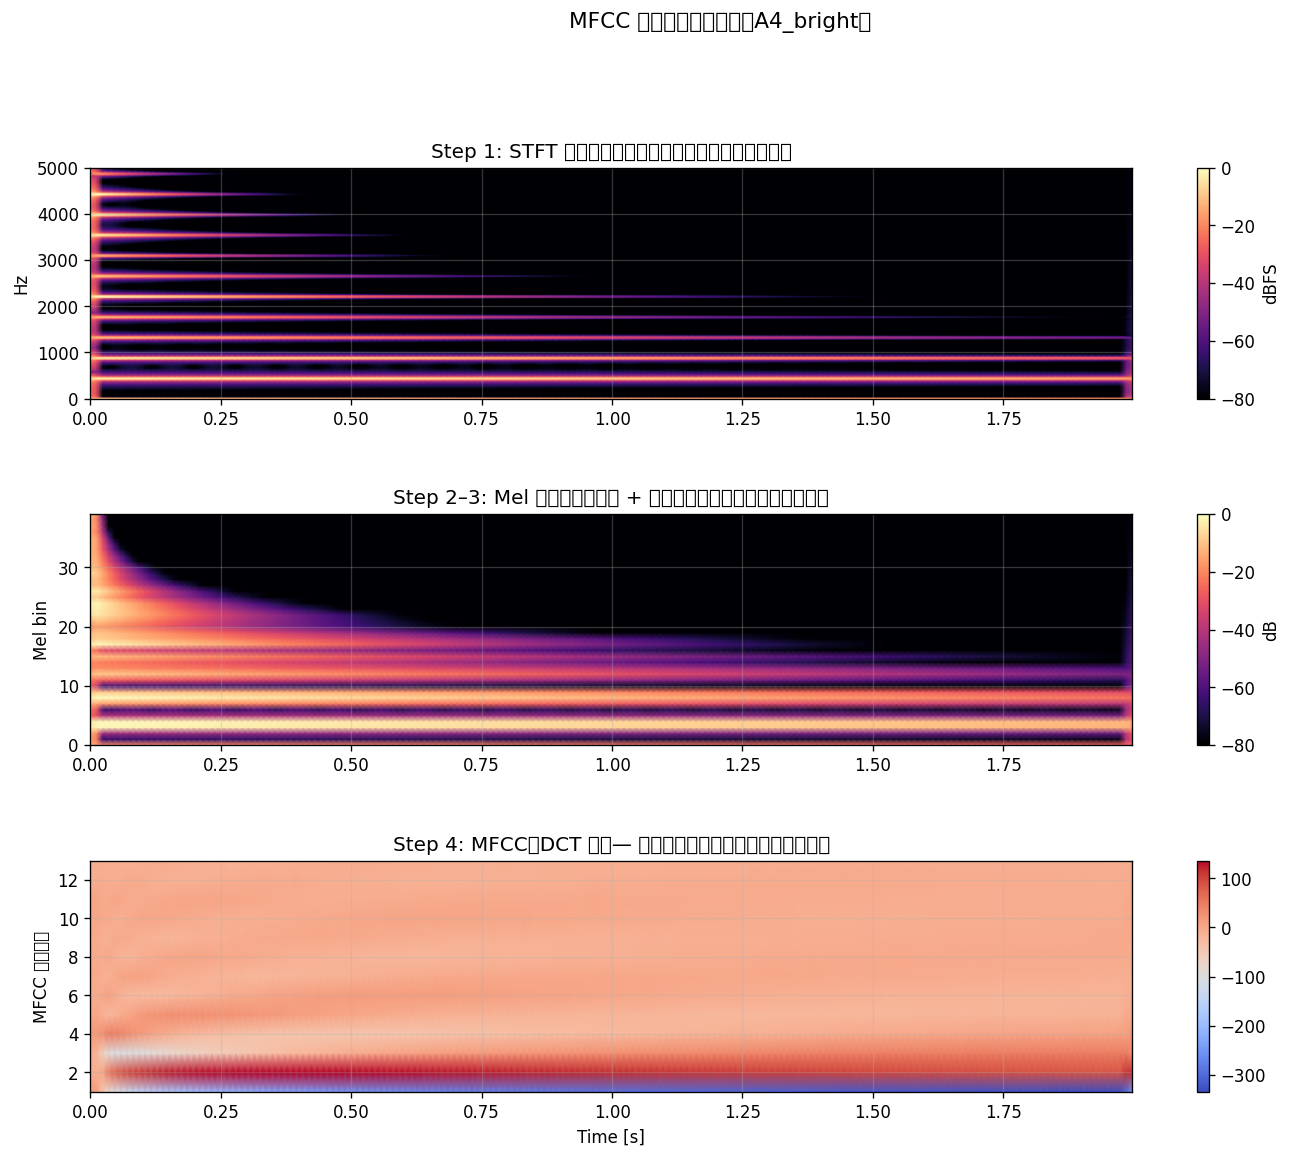

In [3]:
y = waves['A4_bright']
N_MFCC = 13
N_MELS = 40
N_FFT  = 2048
HOP    = 512

# ---- 各ステップを計算 ----
# Step1: STFT パワースペクトル
S_power = np.abs(librosa.stft(y, n_fft=N_FFT, hop_length=HOP)) ** 2

# Step2: Mel フィルタバンク → Mel スペクトログラム
mel_fb  = librosa.filters.mel(sr=SR, n_fft=N_FFT, n_mels=N_MELS)
S_mel   = mel_fb @ S_power

# Step3: 対数変換
S_mel_db = librosa.power_to_db(S_mel, ref=np.max)

# Step4: DCT → MFCC
mfcc = librosa.feature.mfcc(y=y, sr=SR, n_mfcc=N_MFCC,
                              n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP)

times = librosa.frames_to_time(np.arange(mfcc.shape[1]), sr=SR, hop_length=HOP)

# ---- 可視化 ----
fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.5, wspace=0.3)

# STFTパワースペクトル
ax0 = fig.add_subplot(gs[0, :])
freqs_fft = librosa.fft_frequencies(sr=SR, n_fft=N_FFT)
im0 = ax0.pcolormesh(times, freqs_fft,
                     librosa.power_to_db(S_power, ref=np.max),
                     shading='gouraud', cmap='magma', vmin=-80, vmax=0)
ax0.set_ylim(0, 5000)
ax0.set_ylabel('Hz')
ax0.set_title('Step 1: STFT パワースペクトル（線形周波数スケール）')
plt.colorbar(im0, ax=ax0, label='dBFS')

# Mel スペクトログラム
ax1 = fig.add_subplot(gs[1, :])
mel_freqs = librosa.mel_frequencies(n_mels=N_MELS, fmin=0, fmax=SR//2)
im1 = ax1.pcolormesh(times, np.arange(N_MELS), S_mel_db,
                     shading='gouraud', cmap='magma', vmin=-80, vmax=0)
ax1.set_ylabel('Mel bin')
ax1.set_title('Step 2–3: Mel フィルタバンク + 対数変換（対数周波数スケール）')
plt.colorbar(im1, ax=ax1, label='dB')

# MFCC
ax2 = fig.add_subplot(gs[2, :])
im2 = ax2.pcolormesh(times, np.arange(1, N_MFCC+1), mfcc,
                     shading='gouraud', cmap='coolwarm')
ax2.set_ylabel('MFCC 係数番号')
ax2.set_xlabel('Time [s]')
ax2.set_title('Step 4: MFCC（DCT 後）— 音色の「形」が係数列に圧縮される')
plt.colorbar(im2, ax=ax2)

fig.suptitle('MFCC 計算パイプライン（A4_bright）', fontsize=13, y=1.01)
plt.savefig(DATA_DIR / 'mfcc_pipeline.png', bbox_inches='tight')
plt.show()

---
## 3. Δ MFCC と ΔΔ MFCC

MFCC の時間方向の1階差分（Δ）と2階差分（ΔΔ）を加えることで、音の**変化の速さ・加速度**も表現できる。

| 特徴量 | 意味 |
|---|---|
| MFCC | 瞬時の音色の形状（スペクトル包絡） |
| Δ MFCC | 音色の変化速度 |
| ΔΔ MFCC | 音色の変化の加速度 |

Karplus-Strong 音のアタック → サステイン遷移で、Δ が大きくなる区間が確認できる。

/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_88610/2004151655.py:19: UserWarning: Glyph 20418 (\N{CJK UNIFIED IDEOGRAPH-4FC2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_88610/2004151655.py:19: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_88610/2004151655.py:19: UserWarning: Glyph 30058 (\N{CJK UNIFIED IDEOGRAPH-756A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_88610/2004151655.py:19: UserWarning: Glyph 21495 (\N{CJK UNIFIED IDEOGRAPH-53F7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_88610/2004151655.py:19: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkk

/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_88610/2004151655.py:20: UserWarning: Glyph 20418 (\N{CJK UNIFIED IDEOGRAPH-4FC2}) missing from font(s) DejaVu Sans.
  plt.savefig(DATA_DIR / 'mfcc_delta.png', bbox_inches='tight')
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_88610/2004151655.py:20: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.savefig(DATA_DIR / 'mfcc_delta.png', bbox_inches='tight')
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_88610/2004151655.py:20: UserWarning: Glyph 30058 (\N{CJK UNIFIED IDEOGRAPH-756A}) missing from font(s) DejaVu Sans.
  plt.savefig(DATA_DIR / 'mfcc_delta.png', bbox_inches='tight')
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_88610/2004151655.py:20: UserWarning: Glyph 21495 (\N{CJK UNIFIED IDEOGRAPH-53F7}) missing from font(s) DejaVu Sans.
  plt.savefig(DATA_DIR / 'mfcc_delta.png', bbox_inches='tight')
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000

/Users/dolphilia/github/synth-lab/research/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 38745 (\N{CJK UNIFIED IDEOGRAPH-9759}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dolphilia/github/synth-lab/research/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dolphilia/github/synth-lab/research/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12394 (\N{HIRAGANA LETTER NA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dolphilia/github/synth-lab/research/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dolphilia/github/synth-la

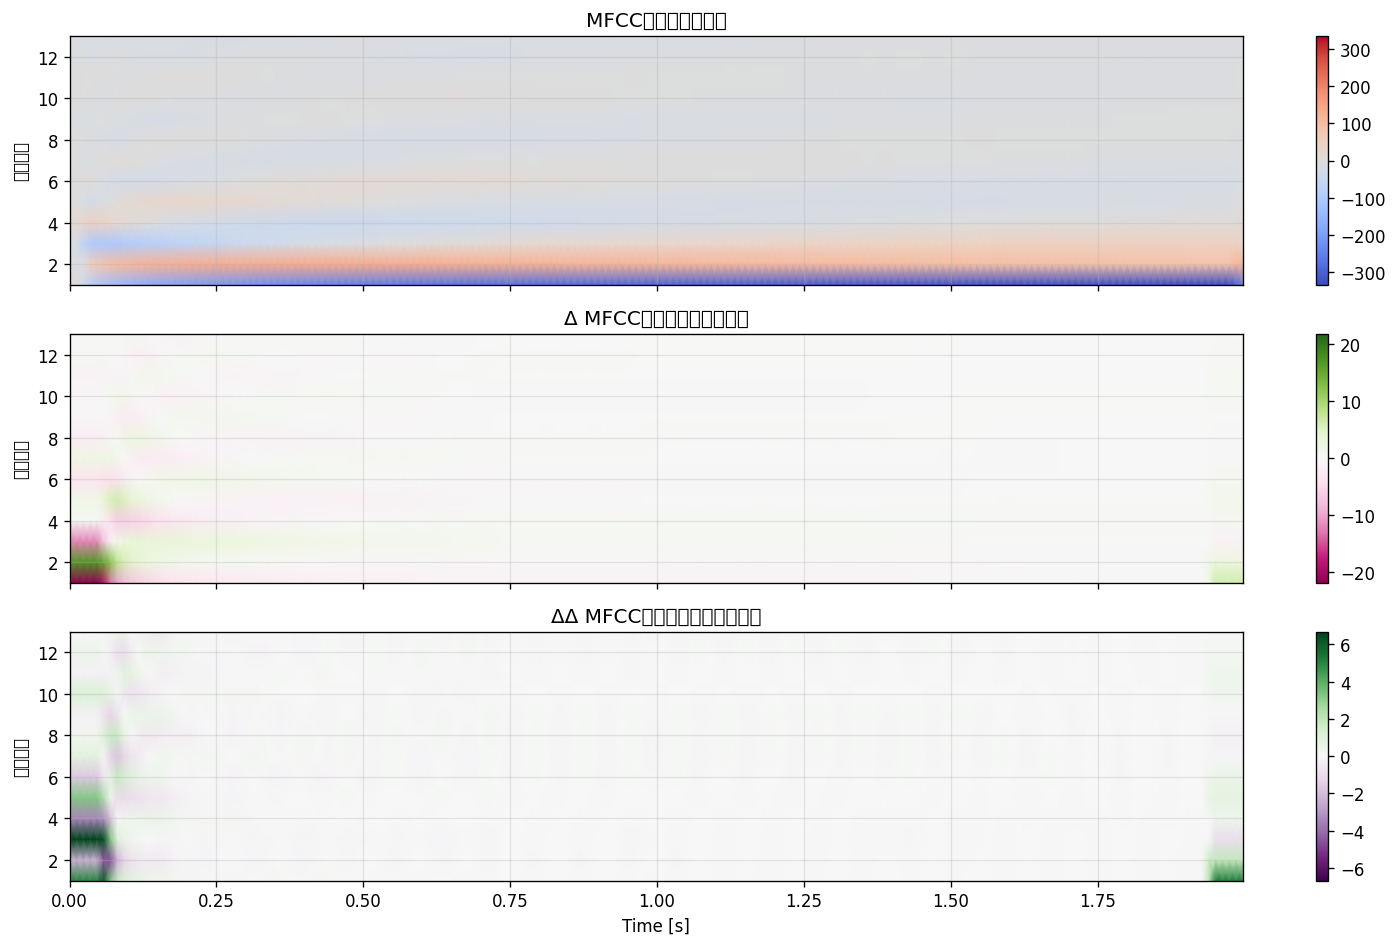

アタック直後（〜0.2s）は Δ MFCC の値が大きく、音色が急変していることが分かる


In [4]:
mfcc_d  = librosa.feature.delta(mfcc)
mfcc_d2 = librosa.feature.delta(mfcc, order=2)

fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)
for ax, data, title, cmap in zip(
    axes,
    [mfcc, mfcc_d, mfcc_d2],
    ['MFCC（静的な音色）', 'Δ MFCC（音色の変化速度）', 'ΔΔ MFCC（音色の変化加速度）'],
    ['coolwarm', 'PiYG', 'PRGn']
):
    vmax = np.max(np.abs(data))
    im = ax.pcolormesh(times, np.arange(1, N_MFCC+1), data,
                       shading='gouraud', cmap=cmap, vmin=-vmax, vmax=vmax)
    ax.set_ylabel('係数番号')
    ax.set_title(title)
    plt.colorbar(im, ax=ax)

axes[-1].set_xlabel('Time [s]')
plt.tight_layout()
plt.savefig(DATA_DIR / 'mfcc_delta.png', bbox_inches='tight')
plt.show()
print('アタック直後（〜0.2s）は Δ MFCC の値が大きく、音色が急変していることが分かる')

---
## 4. 統計的 MFCC ベクトルと音色の比較

各音の MFCC の **時間平均と標準偏差** を連結した固定長ベクトルを作成し、音色間の類似度を比較する。  
このベクトルが音色の「フィンガープリント」になる。

/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_88610/3644358304.py:43: UserWarning: Glyph 12467 (\N{KATAKANA LETTER KO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_88610/3644358304.py:43: UserWarning: Glyph 12469 (\N{KATAKANA LETTER SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_88610/3644358304.py:43: UserWarning: Glyph 12452 (\N{KATAKANA LETTER I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_88610/3644358304.py:43: UserWarning: Glyph 12531 (\N{KATAKANA LETTER N}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_88610/3644358304.py:43: UserWarning: Glyph 39006 (\N{CJK UNIFIED IDEOGRAPH-985E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipyke

/Users/dolphilia/github/synth-lab/research/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12467 (\N{KATAKANA LETTER KO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dolphilia/github/synth-lab/research/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12469 (\N{KATAKANA LETTER SA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dolphilia/github/synth-lab/research/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12452 (\N{KATAKANA LETTER I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dolphilia/github/synth-lab/research/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12531 (\N{KATAKANA LETTER N}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dolphilia/github/synth-lab/research/.venv/lib/pytho

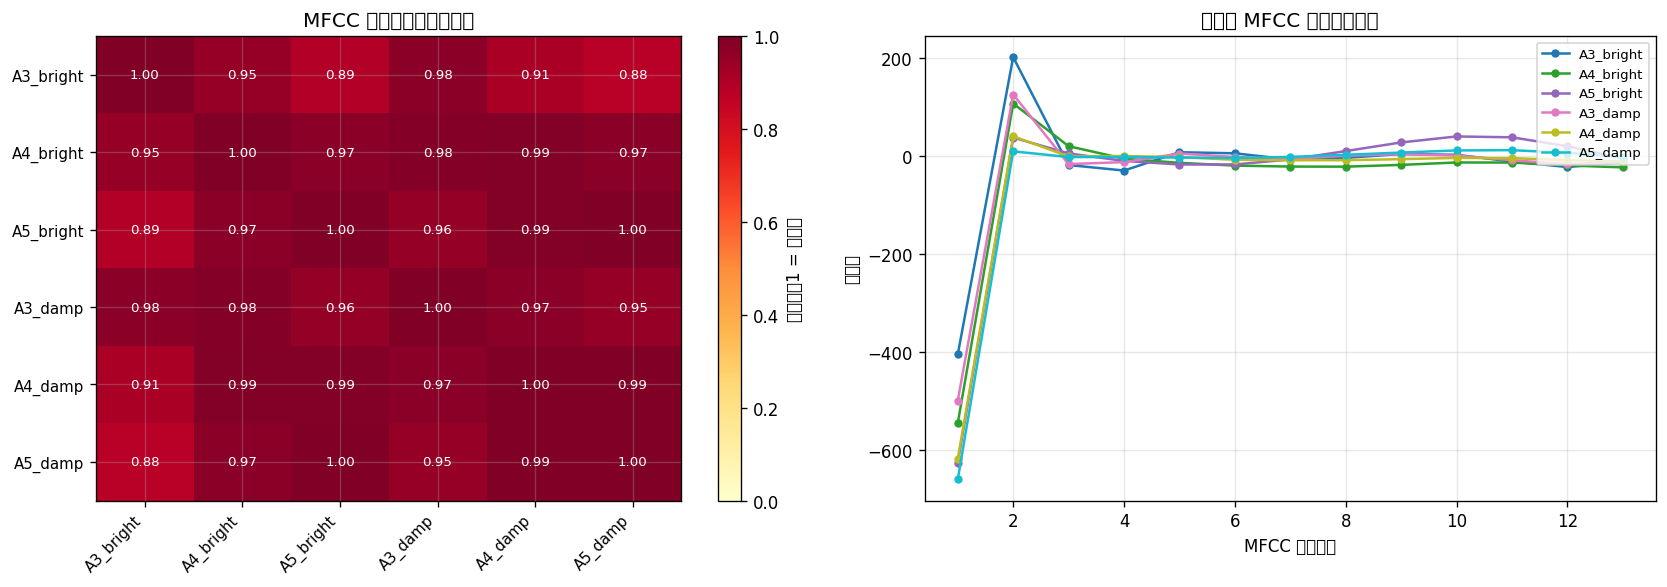

観察ポイント:
  - 同じ decay の bright/damp ペアの類似度が高いか？
  - 同じ周波数での類似度はどうか？


In [5]:
def mfcc_fingerprint(wave, sr=SR, n_mfcc=13):
    """MFCCの平均・標準偏差を連結した固定長ベクトル"""
    m = librosa.feature.mfcc(y=wave, sr=sr, n_mfcc=n_mfcc, hop_length=HOP)
    return np.concatenate([m.mean(axis=1), m.std(axis=1)])


fps = {name: mfcc_fingerprint(w) for name, w in waves.items()}
names = list(fps.keys())
n = len(names)

# コサイン類似度行列
sim_matrix = np.zeros((n, n))
for i, ni in enumerate(names):
    for j, nj in enumerate(names):
        sim_matrix[i, j] = 1.0 - cosine(fps[ni], fps[nj])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---- 類似度行列 ----
im = axes[0].imshow(sim_matrix, cmap='YlOrRd', vmin=0, vmax=1, aspect='auto')
axes[0].set_xticks(range(n))
axes[0].set_yticks(range(n))
axes[0].set_xticklabels(names, rotation=45, ha='right', fontsize=9)
axes[0].set_yticklabels(names, fontsize=9)
axes[0].set_title('MFCC コサイン類似度行列')
plt.colorbar(im, ax=axes[0], label='類似度（1 = 同一）')
for i in range(n):
    for j in range(n):
        axes[0].text(j, i, f'{sim_matrix[i,j]:.2f}',
                    ha='center', va='center', fontsize=8,
                    color='black' if sim_matrix[i,j] < 0.8 else 'white')

# ---- MFCC 平均ベクトルの比較 ----
coeff_idx = np.arange(1, N_MFCC + 1)
colors = plt.cm.tab10(np.linspace(0, 1, n))
for (name, fp), c in zip(fps.items(), colors):
    axes[1].plot(coeff_idx, fp[:N_MFCC], 'o-', label=name, color=c, linewidth=1.5, markersize=4)
axes[1].set_xlabel('MFCC 係数番号')
axes[1].set_ylabel('平均値')
axes[1].set_title('各音の MFCC 平均ベクトル')
axes[1].legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig(DATA_DIR / 'mfcc_similarity.png', bbox_inches='tight')
plt.show()

print('観察ポイント:')
print('  - 同じ decay の bright/damp ペアの類似度が高いか？')
print('  - 同じ周波数での類似度はどうか？')

---
## 5. PCA による音色空間の可視化

MFCC フィンガープリント（高次元ベクトル）を PCA（主成分分析）で 2 次元に圧縮し、音色の「距離」を空間上で可視化する。

/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_88610/3250715147.py:30: UserWarning: Glyph 12501 (\N{KATAKANA LETTER HU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_88610/3250715147.py:30: UserWarning: Glyph 12451 (\N{KATAKANA LETTER SMALL I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_88610/3250715147.py:30: UserWarning: Glyph 12531 (\N{KATAKANA LETTER N}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_88610/3250715147.py:30: UserWarning: Glyph 12460 (\N{KATAKANA LETTER GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_88610/3250715147.py:30: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsb

/Users/dolphilia/github/synth-lab/research/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12501 (\N{KATAKANA LETTER HU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dolphilia/github/synth-lab/research/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12451 (\N{KATAKANA LETTER SMALL I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dolphilia/github/synth-lab/research/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12460 (\N{KATAKANA LETTER GA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dolphilia/github/synth-lab/research/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dolphilia/github/synth-l

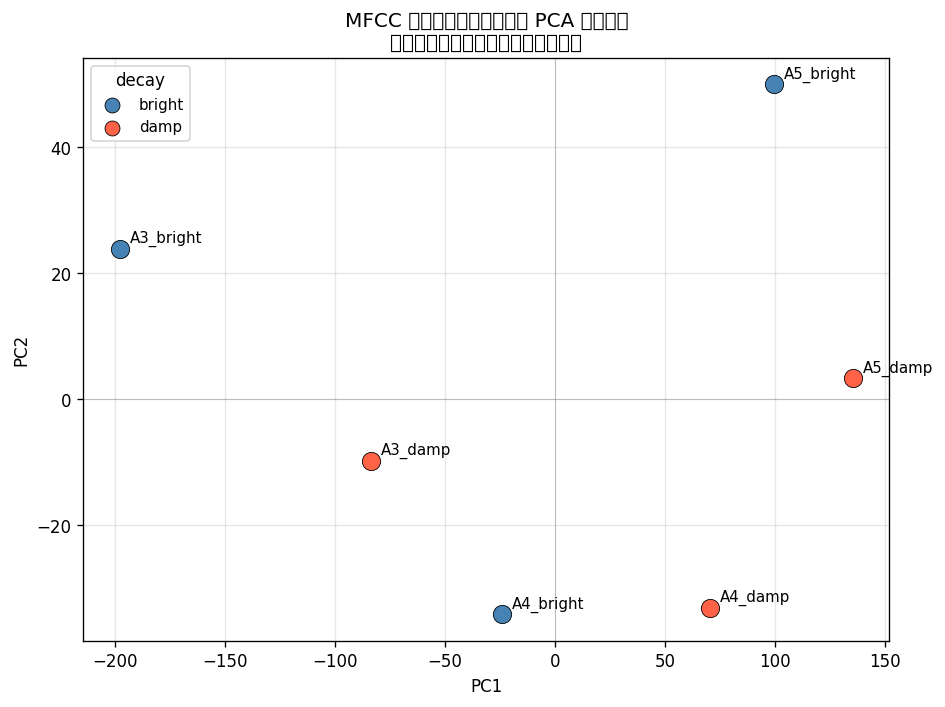

PC1 軸 = 主に周波数（音程）の違いを反映
PC2 軸 = 主に decay（音色の明るさ/ダンプ）の違いを反映することが多い


In [6]:
from numpy.linalg import svd

# PCA（手動実装）
X = np.array(list(fps.values()))     # shape: (n_sounds, n_features)
X_centered = X - X.mean(axis=0)
_, _, Vt = svd(X_centered, full_matrices=False)
X_pca = X_centered @ Vt[:2].T       # 2主成分に射影

fig, ax = plt.subplots(figsize=(8, 6))
group_colors = {'bright': 'steelblue', 'damp': 'tomato'}

for i, name in enumerate(names):
    group = 'bright' if 'bright' in name else 'damp'
    freq  = SOUNDS[name]['freq']
    ax.scatter(*X_pca[i], s=120, color=group_colors[group],
               zorder=3, edgecolors='k', linewidths=0.5)
    ax.annotate(name, X_pca[i], xytext=(6, 4), textcoords='offset points', fontsize=9)

# 凡例
for group, color in group_colors.items():
    ax.scatter([], [], s=80, color=color, label=group, edgecolors='k', linewidths=0.5)
ax.legend(title='decay', fontsize=9)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('MFCC フィンガープリントの PCA 音色空間\n（距離が近いほど音色が似ている）')
ax.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
ax.axvline(0, color='gray', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.savefig(DATA_DIR / 'mfcc_pca.png', bbox_inches='tight')
plt.show()
print('PC1 軸 = 主に周波数（音程）の違いを反映')
print('PC2 軸 = 主に decay（音色の明るさ/ダンプ）の違いを反映することが多い')

---
## まとめ

| 確認できたこと | 詳細 |
|---|---|
| パイプライン | STFTパワー → Mel変換 → log → DCT という段階的な変換 |
| 係数の意味 | 低次係数 = スペクトルの大まかな形状、高次 = 細部 |
| Δ MFCC | アタック直後に変化が激しく、サステインは安定する |
| 類似度比較 | 同じ周波数の bright/damp は意外と類似度が低い（音色の差がある） |
| PCA 音色空間 | 周波数（音程）と decay の違いが異なる軸に分離して現れる |

### 次に試すこと

- FM 合成・PCM サンプルなど異なる合成手法の音と MFCC を比較する
- `n_mfcc` を増やしてより細かい音色の差を捉える
- 機械学習モデル（k-NN, SVM）に MFCC フィンガープリントを入力して音色分類を試す